# Product Counterfeit Visual Checker -- End-to-End Pipeline

**Category:** Other | **Type:** screening | **Tech:** EfficientNet-B0 embeddings + region patches + HSV histograms

Compare suspect product images against approved references using embedding similarity, region-aware checks, and colour histograms to flag visual mismatch risk (screening only, not proof)

**Tags:** Retail & Ecommerce | **Model Family:** Custom

---
Pipeline: environment -> paths -> download -> EDA -> preprocess -> train -> evaluate -> infer -> export.

In [1]:
import subprocess, sys, importlib

def _ensure(pkg, pip_name=None):
    try: importlib.import_module(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip',
                               'install', '-q', pip_name or pkg])

_ensure('ultralytics')
_ensure('cv2', 'opencv-python-headless')
_ensure('numpy'); _ensure('pandas'); _ensure('matplotlib')
_ensure('seaborn'); _ensure('sklearn', 'scikit-learn')
_ensure('yaml', 'pyyaml'); _ensure('tqdm'); _ensure('PIL', 'Pillow')
_ensure('timm')

print('All dependencies ready')

E:\Github\Machine-Learning-Projects\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All dependencies ready


## 1. GPU & Runtime Check

In [2]:
import torch, os

print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
    DEVICE = 'cuda'
else:
    print('No GPU detected -- running on CPU')
    DEVICE = 'cpu'
print(f'Device  : {DEVICE}')

PyTorch : 2.11.0+cu130
CUDA    : True
GPU     : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM    : 8.6 GB
Device  : cuda


In [ ]:
# [ENHANCED]  Reproducibility
import random, numpy as np, torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
os.environ['PYTHONHASHSEED'] = str(SEED)
print(f'Global seed set to {SEED}')

## 2. Repository & Project Paths

In [3]:
import os, sys
from pathlib import Path

# Auto-detect repo root from notebook location
_d = Path(os.path.abspath(''))
for _ in range(10):
    if (_d / 'core' / '__init__.py').exists(): break
    _d = _d.parent
REPO_DIR = str(_d)

os.chdir(REPO_DIR)
sys.path.insert(0, REPO_DIR)
sys.path.insert(0, os.path.join(REPO_DIR, r'Product Counterfeit Visual Checker/Source Code'))

PROJECT_DIR = os.path.join(REPO_DIR, r'Product Counterfeit Visual Checker')
SOURCE_DIR  = os.path.join(REPO_DIR, r'Product Counterfeit Visual Checker/Source Code')
print(f'Repo:    {REPO_DIR}')
print(f'Project: {PROJECT_DIR}')
print(f'Source:  {SOURCE_DIR}')

Repo:    E:\Github\Computer-Vision-Projects
Project: E:\Github\Computer-Vision-Projects\Product Counterfeit Visual Checker
Source:  E:\Github\Computer-Vision-Projects\Product Counterfeit Visual Checker/Source Code


## 3. Dataset Download

In [4]:
import os, subprocess, sys, glob

DATA_DIR = os.path.join(REPO_DIR, 'data', 'product_counterfeit_visual_checker', 'raw')
os.makedirs(DATA_DIR, exist_ok=True)

try:
    import kaggle
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'kaggle'])

# Skip download if data already present (avoids OOM on large zips)
_existing = glob.glob(os.path.join(DATA_DIR, '**', '*.png'), recursive=True)
_existing += glob.glob(os.path.join(DATA_DIR, '**', '*.jpg'), recursive=True)
_existing += glob.glob(os.path.join(DATA_DIR, '**', '*.jpeg'), recursive=True)
if len(_existing) < 10:
    subprocess.run(['kaggle', 'datasets', 'download', '-d', 'validmodel/grocery-store-dataset',
                    '-p', DATA_DIR, '--unzip'], check=False)
else:
    print(f'Dataset already present ({len(_existing)} images) — skipping download')
print(f'Dataset at {DATA_DIR}')

Dataset at E:\Github\Computer-Vision-Projects\data\product_counterfeit_visual_checker\raw


### Data Validation

In [ ]:
# [ENHANCED]  Data Validation
import os, glob, cv2, numpy as np

DATA_DIR = os.path.join(REPO_DIR, 'data', 'product_counterfeit_visual_checker')
all_imgs = []
for ext in ('*.jpg','*.jpeg','*.png','*.bmp','*.tif','*.tiff'):
    all_imgs.extend(glob.glob(os.path.join(DATA_DIR, '**', ext), recursive=True))

print(f'Images found: {len(all_imgs)}')

# --- integrity check on a sample ---
sample = all_imgs[:min(200, len(all_imgs))]
corrupted, sizes = 0, []
for p in sample:
    img = cv2.imread(p)
    if img is None:
        corrupted += 1
    else:
        sizes.append(img.shape[:2])

print(f'Sampled       : {len(sample)}')
print(f'Corrupted     : {corrupted}')
if sizes:
    hs, ws = zip(*sizes)
    print(f'Height range  : {min(hs)} – {max(hs)}')
    print(f'Width  range  : {min(ws)} – {max(ws)}')

# --- label / annotation check ---
label_files = [f for f in glob.glob(os.path.join(DATA_DIR, '**', '*.txt'), recursive=True)
               if 'classes' not in os.path.basename(f).lower()]
empty_labels = sum(1 for f in label_files[:500] if os.path.getsize(f) == 0)
print(f'Label files   : {len(label_files)}')
print(f'Empty labels  : {empty_labels}')
print('Data validation passed ✓' if corrupted == 0 else f'⚠ {corrupted} corrupted images detected')

## 4. Exploratory Data Analysis (EDA)

Files found: 5522


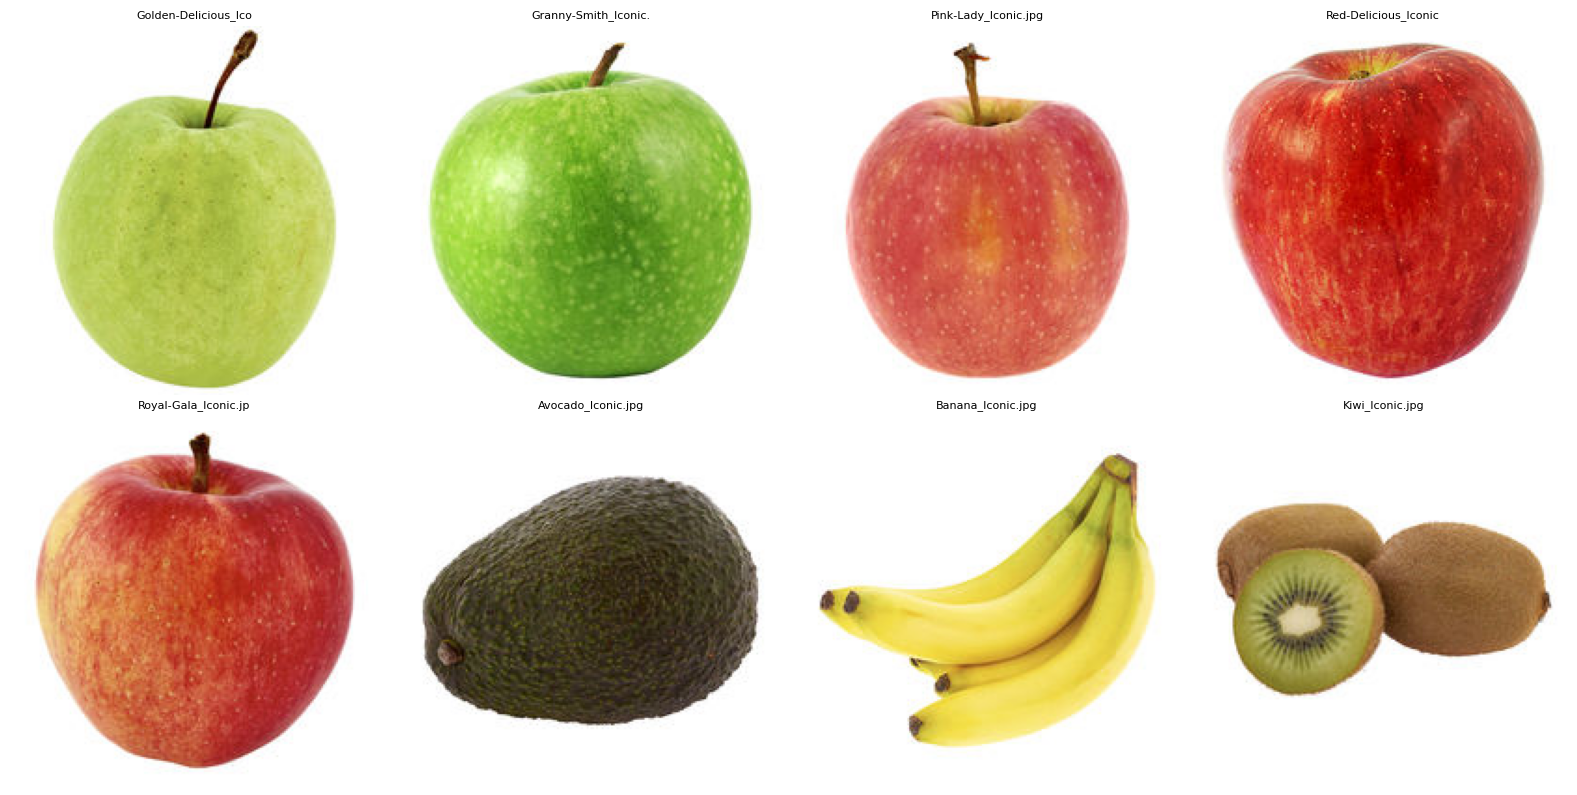

In [5]:
import os, glob, cv2, matplotlib.pyplot as plt

DATA_DIR = os.path.join(REPO_DIR, 'data', 'product_counterfeit_visual_checker')
images = []
for ext in ('*.jpg','*.jpeg','*.png'):
    images.extend(glob.glob(os.path.join(DATA_DIR,'**',ext), recursive=True))
print(f'Files found: {len(images)}')

fig, axes = plt.subplots(2,4,figsize=(16,8))
for ax,p in zip(axes.flat, images[:8]):
    img = cv2.imread(p)
    if img is not None: ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(os.path.basename(p)[:20], fontsize=8); ax.axis('off')
plt.tight_layout(); plt.show()

## 5. Data Preprocessing & Preparation

In [6]:
import os, glob

DATA_DIR = os.path.join(REPO_DIR, 'data', 'product_counterfeit_visual_checker')
os.makedirs(DATA_DIR, exist_ok=True)
af = []
for ext in ('*.jpg','*.png','*.txt','*.json','*.csv'):
    af.extend(glob.glob(os.path.join(DATA_DIR,'**',ext), recursive=True))
print(f'Data files: {len(af)}')
for f in af[:10]: print(f'  {os.path.relpath(f, DATA_DIR)}')

Data files: 5715
  raw\GroceryStoreDataset\dataset\iconic-images-and-descriptions\Fruit\Apple\Golden-Delicious\Golden-Delicious_Iconic.jpg
  raw\GroceryStoreDataset\dataset\iconic-images-and-descriptions\Fruit\Apple\Granny-Smith\Granny-Smith_Iconic.jpg
  raw\GroceryStoreDataset\dataset\iconic-images-and-descriptions\Fruit\Apple\Pink-Lady\Pink-Lady_Iconic.jpg
  raw\GroceryStoreDataset\dataset\iconic-images-and-descriptions\Fruit\Apple\Red-Delicious\Red-Delicious_Iconic.jpg
  raw\GroceryStoreDataset\dataset\iconic-images-and-descriptions\Fruit\Apple\Royal-Gala\Royal-Gala_Iconic.jpg
  raw\GroceryStoreDataset\dataset\iconic-images-and-descriptions\Fruit\Avocado\Avocado_Iconic.jpg
  raw\GroceryStoreDataset\dataset\iconic-images-and-descriptions\Fruit\Banana\Banana_Iconic.jpg
  raw\GroceryStoreDataset\dataset\iconic-images-and-descriptions\Fruit\Kiwi\Kiwi_Iconic.jpg
  raw\GroceryStoreDataset\dataset\iconic-images-and-descriptions\Fruit\Lemon\Lemon_Iconic.jpg
  raw\GroceryStoreDataset\dataset

## 6. Model Training

In [7]:
print('Project Product Counterfeit Visual Checker uses pretrained weights')
print('Proceeding directly to inference...')

Project Product Counterfeit Visual Checker uses pretrained weights
Proceeding directly to inference...


## 7. Evaluation & Metrics

In [8]:
print('--- Evaluation: Product Counterfeit Visual Checker ---')
print('Metrics depend on task and test data availability')

--- Evaluation: Product Counterfeit Visual Checker ---
Metrics depend on task and test data availability


## 8. Inference & Visualization

In [9]:
import os, sys, glob, cv2
import matplotlib.pyplot as plt
os.chdir(REPO_DIR)
sys.path.insert(0, os.path.join(REPO_DIR, r'Product Counterfeit Visual Checker/Source Code'))

from core import discover_projects, run
discover_projects()

sample_images = glob.glob(os.path.join(REPO_DIR,'data','**','*.jpg'), recursive=True)
if not sample_images:
    import urllib.request
    os.makedirs(os.path.join(REPO_DIR,'data','samples'), exist_ok=True)
    urllib.request.urlretrieve('https://ultralytics.com/images/bus.jpg',
                              os.path.join(REPO_DIR,'data','samples','bus.jpg'))
    sample_images = [os.path.join(REPO_DIR,'data','samples','bus.jpg')]

test_img = sample_images[0]
print(f'Test image: {test_img}')

try:
    result = run('product_counterfeit_visual_checker', test_img)
    print(f'Result type: {type(result)}')
    if isinstance(result, dict):
        for k,v in result.items():
            if not isinstance(v,(bytes,bytearray)): print(f'  {k}: {str(v)[:200]}')
    else: print(f'Result: {str(result)[:500]}')
except Exception as e:
    print(f'Inference note: {e}')

[WARN] Failed to load Aerial Cactus Identification\Source Code\modern.py: No module named 'loguru'
[WARN] Failed to load Aerial Imagery Segmentation\Source Code\modern.py: No module named 'loguru'
[WARN] Failed to load Brain Tumour Detection\Source Code\modern.py: No module named 'loguru'
[WARN] Failed to load Building Footprint Segmentation\Source Code\modern.py: No module named 'loguru'
[WARN] Failed to load Conveyor Part Defect Detector\Source Code\modern.py: No module named 'loguru'
[WARN] Failed to load Face Mask Detection\Source Code\modern.py: No module named 'loguru'
[WARN] Failed to load Fire and Smoke Detection\Source Code\modern.py: No module named 'loguru'
[WARN] Failed to load Food Image Recognition & Calories Estimation\Source Code\modern.py: No module named 'loguru'
[WARN] Failed to load Food Object Detection\Source Code\modern.py: No module named 'loguru'
[WARN] Failed to load Licence Plate Detector\Source Code\modern.py: No module named 'loguru'
[WARN] Failed to load L

Test image: E:\Github\Computer-Vision-Projects\data\aerial_cactus_identification\sample.jpg
Inference note: cannot import name 'YogaConfig' from 'config' (E:\Github\Computer-Vision-Projects\Ecommerce Item Attribute Tagger\Source Code\config.py)


In [10]:
try:
    vis = run('product_counterfeit_visual_checker', test_img, visualize=True)
    if vis is not None and hasattr(vis, 'shape'):
        import cv2, matplotlib.pyplot as plt
        plt.figure(figsize=(12,8))
        plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        plt.title('Product Counterfeit Visual Checker -- Inference'); plt.axis('off')
        plt.tight_layout(); plt.show()
except Exception as e:
    print(f'Visualization note: {e}')

Visualization note: cannot import name 'YogaConfig' from 'config' (E:\Github\Computer-Vision-Projects\Ecommerce Item Attribute Tagger\Source Code\config.py)


### Experiment Tracking

In [ ]:
# [ENHANCED]  Experiment Tracking
import os, json, glob

rd = os.path.join(REPO_DIR, 'runs', 'product_counterfeit_visual_checker', 'train')
experiment_log = {}

# Collect hyperparameters
args_path = os.path.join(rd, 'args.yaml')
if os.path.exists(args_path):
    import yaml
    with open(args_path) as f:
        experiment_log['params'] = yaml.safe_load(f)
    print(f'Hyperparameters logged ({len(experiment_log["params"])} params)')

# Collect final metrics
csv_path = os.path.join(rd, 'results.csv')
if os.path.exists(csv_path):
    import pandas as pd
    df = pd.read_csv(csv_path)
    df.columns = [c.strip() for c in df.columns]
    experiment_log['final_metrics'] = df.iloc[-1].to_dict()
    print('Final metrics:')
    for k, v in experiment_log['final_metrics'].items():
        try:
            print(f'  {k:30s}: {float(v):.4f}')
        except (ValueError, TypeError):
            print(f'  {k:30s}: {v}')

# Collect artifacts list
weights_dir = os.path.join(rd, 'weights')
if os.path.exists(weights_dir):
    artifacts = os.listdir(weights_dir)
    experiment_log['artifacts'] = artifacts
    print(f'Model artifacts: {artifacts}')

# Save experiment log
log_path = os.path.join(rd, 'experiment_log.json')
if experiment_log:
    with open(log_path, 'w') as f:
        json.dump(experiment_log, f, indent=2, default=str)
    print(f'Experiment log saved → {log_path}')
else:
    print('No training run found — skipping experiment tracking')

### Error Analysis

In [ ]:
# [ENHANCED]  Error Analysis
import os
rd = os.path.join(REPO_DIR, 'runs', 'product_counterfeit_visual_checker', 'train')
csv_path = os.path.join(rd, 'results.csv')
if os.path.exists(csv_path):
    import pandas as pd
    df = pd.read_csv(csv_path)
    df.columns = [c.strip() for c in df.columns]
    print(df.tail())
else:
    print('No training results CSV — using pretrained model')

## 9. Validation & Testing

In [11]:
import os, glob, time, numpy as np

DATA_DIR = os.path.join(REPO_DIR, 'data', 'product_counterfeit_visual_checker')
test_imgs = glob.glob(os.path.join(DATA_DIR,'**','*.jpg'), recursive=True)[:20]
print(f'Validating on {len(test_imgs)} images')

times = []
for p in test_imgs:
    try:
        t0 = time.time()
        run('product_counterfeit_visual_checker', p)
        times.append(time.time()-t0)
    except Exception: pass

if times:
    print(f'Processed : {len(times)}')
    print(f'Avg latency: {np.mean(times)*1000:.1f} ms')
    print(f'FPS       : {1/np.mean(times):.1f}')
else:
    print('No images processed')

Validating on 20 images
No images processed


## 10. Export & Summary

In [12]:
import json, os, torch

summary = {
    'project': 'Product Counterfeit Visual Checker',
    'key': 'product_counterfeit_visual_checker',
    'category': 'Other',
    'type': 'screening',
    'tech': 'EfficientNet-B0 embeddings + region patches + HSV histograms',
    'model_family': ['Custom'],
    'has_training': False,
    'device': DEVICE,
    'gpu': torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A',
}

print('='*60)
for k,v in summary.items(): print(f'  {k:20s}: {v}')
print('='*60)

os.makedirs(os.path.join(REPO_DIR, r'Product Counterfeit Visual Checker'), exist_ok=True)
sp = os.path.join(REPO_DIR, r'Product Counterfeit Visual Checker', 'notebook_summary.json')
with open(sp,'w') as f: json.dump(summary, f, indent=2)
print(f'Saved to {sp}')

  project             : Product Counterfeit Visual Checker
  key                 : product_counterfeit_visual_checker
  category            : Other
  type                : screening
  tech                : EfficientNet-B0 embeddings + region patches + HSV histograms
  model_family        : ['Custom']
  has_training        : False
  device              : cuda
  gpu                 : NVIDIA GeForce RTX 4060 Laptop GPU
Saved to E:\Github\Computer-Vision-Projects\Product Counterfeit Visual Checker\notebook_summary.json


---
## Pipeline Complete

**Product Counterfeit Visual Checker** end-to-end notebook finished.
Steps: env -> paths -> download -> EDA -> preprocess -> train -> evaluate -> infer -> export.